## Final step - 5b

let's employ our transformer power on the shakespeare task! no need for tiny this time

this will ber a little different to 5 (a) in that it will be decoder only this time

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datetime import date, timedelta
import random
import string

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device("mps")

In [3]:
# Inspect the txt (not tiny) file
with open("data/shakespeare.txt") as f:
    data = f.read()

print(len(data))
tokens = list(set(data))
VOCAB_SIZE = len(tokens)
print(VOCAB_SIZE)
print(torch.log2(torch.tensor(len(data))))

c2i = {c: i for i, c in enumerate(tokens)}
i2c = {i: c for c, i in c2i.items()}

TRAIN_PCT = 0.9
SPLIT_IDX = int(len(data) * TRAIN_PCT)
NUM_CTX = 256

5436475
84
tensor(22.3742)


In [4]:
class ShakespeareDataset(Dataset):

    def __init__(self, test: bool = False, num_ctx: int = NUM_CTX, epoch_size: int = 16384):
        self.test = test
        self.num_ctx = num_ctx
        self.epoch_size = epoch_size  # roughly len(data) // num_ctx: 2^22 / 2^8 = 16384

        if self.test:
            self.data = data[SPLIT_IDX:]
        else:
            self.data = data[:SPLIT_IDX]

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, _):
        start_idx = torch.randint(0, len(self.data) - self.num_ctx, (1,))
        seq_char = self.data[start_idx : start_idx + self.num_ctx]
        seq = torch.tensor([c2i[c] for c in seq_char])
        x = seq[:-1]
        y = seq[1:]
        return x, y


ds_train = ShakespeareDataset(test=False)
ds_test = ShakespeareDataset(test=True)
dl_train = DataLoader(ds_train, batch_size=16)
dl_test = DataLoader(ds_test, batch_size=16)

In [5]:
# reuse this from stage_5.ipyn as is. will need to be masked=True all the time
class SelfAttentionMultiHead(nn.Module):
    def __init__(self, d: int, h, masked: bool = False):
        super().__init__()

        assert h > 0
        assert d % h == 0
        self.h = h
        self.d = d
        self.d_h = d // h
        self.masked = masked

        # assume d_h = d/h
        self.K = nn.Linear(d, d, bias=False)
        self.Q = nn.Linear(d, d, bias=False)
        self.V = nn.Linear(d, d, bias=False)
        self.W0 = nn.Linear(d, d, bias=False)

    def forward(self, x):
        # x is (B, T, d)
        B, T, d = x.shape

        keys = self.K(x).view(B, T, self.h, self.d_h).transpose(1, 2)
        queries = self.Q(x).view(B, T, self.h, self.d_h).transpose(1, 2)
        values = self.V(x).view(B, T, self.h, self.d_h).transpose(1, 2)

        # key-query affinities
        e = queries @ torch.transpose(keys, -1, -2)  # (B, H, T, T)
        e /= self.d_h**0.5  # "scaled" part, now by d_h

        # causal/masking here!
        # make all "future" positions in the affinities be -inf
        if self.masked:
            causal_mask = (
                ~torch.tril(torch.ones((T, T), dtype=torch.bool))
                .unsqueeze(0)
                .unsqueeze(0)
            ).to(x.device)
            e.masked_fill_(causal_mask, -torch.inf)

        # attention weights
        alpha = torch.softmax(e, dim=-1)

        outputs = alpha @ values
        outputs.transpose_(1, 2)  # (B, H, T, d_h) -> (B, T, H, d_h)
        outputs = torch.reshape(outputs, (B, T, -1))
        outputs = self.W0(outputs)

        return outputs

class DecoderBlock(nn.Module):
    def __init__(self, d: int):
        super().__init__()

        # 1. casusal/masked self attn
        self.attn = SelfAttentionMultiHead(d, h=4, masked=True)

        # 2. residual + layernorm
        self.ln1 = nn.LayerNorm(d)

        # 3. ff
        d_ff = d * 4
        self.ff1 = nn.Linear(d, d_ff)
        self.ff2 = nn.Linear(d_ff, d)

        # 4. residual + layernorm
        self.ln2 = nn.LayerNorm(d)  # just over feature dim

    def forward(self, x):
        x1 = self.attn(x)
        x2 = self.ln1(x + x1)

        x3 = self.ff2(torch.relu(self.ff1(x2)))

        x4 = self.ln2(x2 + x3)

        return x4


class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        max_ctx: int,
        embedding_size: int = 16,
        n_dec_blocks: int = 2,
    ):
        super().__init__()
        self.embedding_size = embedding_size
        self.n_dec_blocks = n_dec_blocks
        self.max_ctx = max_ctx

        # emb
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)

        # positional encoding
        self.register_buffer("pos_enc", self._build_pos_enc())

        # dec
        self.dec_blocks = nn.ModuleList([])
        for _ in range(n_dec_blocks):
            self.dec_blocks.append(DecoderBlock(d=self.embedding_size))

        # final layer
        self.ff = nn.Linear(embedding_size, VOCAB_SIZE)

    def _build_pos_enc(self):
        # build out (n, d) matrix with just row index in each col (numerator)
        r = torch.arange(1, self.max_ctx + 1)
        pos_enc = torch.vstack([r for _ in range(self.embedding_size)]).T

        # the denominator, 10K comes from the orginal paper
        col = 10_000 ** (
            2 * (torch.arange(0, self.embedding_size) // 2) / self.embedding_size
        )

        # form the fraction within each trig function
        pos_enc = pos_enc / col.repeat(self.max_ctx).view(
            self.max_ctx, self.embedding_size
        )

        # apply to alternating columms
        pos_enc[:, ::2].sin_()
        pos_enc[:, 1::2].cos_()

        return pos_enc

    def forward(self, x):
        """
        - x: (B, S) integer character IDs. no padding
        """
        B, S = x.shape

        # Decoder
        x_dec = self.emb(x) + self.pos_enc[:S, :]
        for dec in self.dec_blocks:
            x_dec = dec(x_dec)

        out = self.ff(x_dec)

        return out

## training

can pretty well reuse, with teacher forcing

In [10]:
def get_test_loss(model, dl_test):
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            y_pred = model(x)

            # flatten
            logits = y_pred.flatten(0, 1)  # (B, T, VOCAB_SIZE) -> (B * T, -1)
            labels = y.flatten()  # -> (B * T,)
            loss = loss_fn(logits, labels)

            total_loss += loss * x.size(0)
    return (total_loss / len(dl_test.dataset)).item()


def train(
    model: nn.Module, dl_train: DataLoader, dl_test: DataLoader, n_epochs: int = 10
):
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    pbar = tqdm(range(n_epochs))

    train_losses = []
    test_losses = []
    for _ in pbar:
        total_loss = 0
        model.train()
        for x, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optim.zero_grad()
            y_pred = model(x)

            # flatten
            logits = y_pred.flatten(0, 1)  # (B, T, VOCAB_SIZE) -> (B * T, -1)
            labels = y.flatten()  # -> (B * T,)
            loss = loss_fn(logits, labels)

            loss.backward()
            optim.step()

            total_loss += loss.detach() * x.size(0)

        avg_loss = (total_loss / len(dl_train.dataset)).item()
        train_losses.append(avg_loss)
        test_loss = get_test_loss(model, dl_test)
        test_losses.append(test_loss)
        pbar.set_postfix({"Train loss": avg_loss})

    return train_losses, test_losses

100%|██████████| 10/10 [04:50<00:00, 29.04s/it, Train loss=1.22]


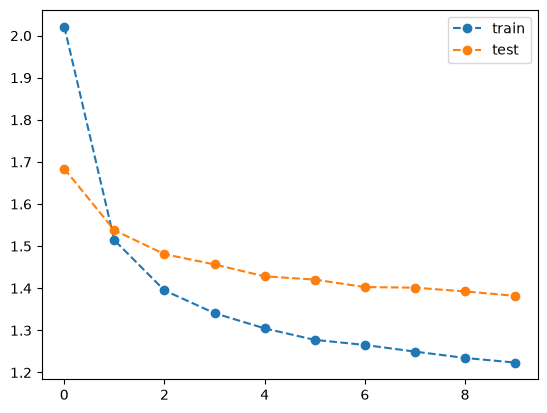

In [45]:
# Give it a whirl!

model = DecoderOnlyTransformer(max_ctx=NUM_CTX, embedding_size=128, n_dec_blocks=4).to(
    DEVICE
)
train_losses, test_losses = train(model, dl_train, dl_test)

plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

In [46]:
def sample(model: DecoderOnlyTransformer, prefix: str = "\n", seq_len: int = 256) -> str:
    # tokenize the prefix
    x = torch.tensor([c2i[c] for c in prefix]).to(DEVICE)
    x = x.unsqueeze(0) # add dummy batch

    chars = [c for c in prefix]
    model.eval()
    with torch.no_grad():
        for _ in range(seq_len - len(prefix)):
            y_pred = model.forward(x)
            logits = y_pred[-1, -1, :]
            probs = logits.softmax(0)

            pred_idx = torch.multinomial(probs, 1).item()

            pred_char = i2c[pred_idx]
            chars.append(pred_char)
            
            # update x
            pred_token = torch.tensor([pred_idx]).to(DEVICE).unsqueeze(0)
            x = torch.cat([x, pred_token], dim=1)

    return "".join(chars)

In [50]:
generation = sample(model)
print(generation)


    After mine throat, and she did ever full

                    Enter PAROLLAS

  VENTILENIUS. What, my lord?
  TITUS. My liege air, thou art my your favour is avoided and the
    worser you. I take your surely; God perhaps you for this,
    our pardon 


---
### attempt 1

as a note, with n=2, h =4 , d= 16, got to 2.12 train loss and pretty poor generations

```

                      Toucem: Bel THERANEMENMNON'MEUPRT. Aullerined,
    Met natakeng, thenkes.
             ERIAMAS

<<RUIO. IUSqu: WICLLIANR


US ORINTETh WET SERIEIS. Co ALontity the ake yo is hes sroun clowsthwss
   PRINGUMRD Lystomarsth shes hig sang
   ```

---

### attempt 2

Let's try bumping it up a bit to d=64

> 100%|██████████| 10/10 [01:55<00:00, 11.51s/it, Train loss=1.51]

n=2, h=4, d=64. 1.51 train loss w/ 

```
     The bland seaw the viouse, pursuit spurpect we,
  Bent, and soldiers, to Thou slents not to cantages,
    You exaced fight so oughs, which, upor of my from.
  DUCIANUS. Yore would to ki' it should him man;
    But, rathers, I had is breed for donesse
```

---

### attempt 3

going bigger once more to around 1M params

> 100%|██████████| 10/10 [04:50<00:00, 29.04s/it, Train loss=1.22]

n=4, h=4, d=128

```
    After mine throat, and she did ever full

                    Enter PAROLLAS

  VENTILENIUS. What, my lord?
  TITUS. My liege air, thou art my your favour is avoided and the
    worser you. I take your surely; God perhaps you for this,
    our pardon 
```